FiLM Conditioning:

--------------------------------
- Spatially modulated linear regression
- Baseline MLP vs FiLM-conditioned MLP + variants + visualizations

In [3]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from dataclasses import dataclass

# Toy Data

TypeError: Axes.scatter() got multiple values for argument 'ax'

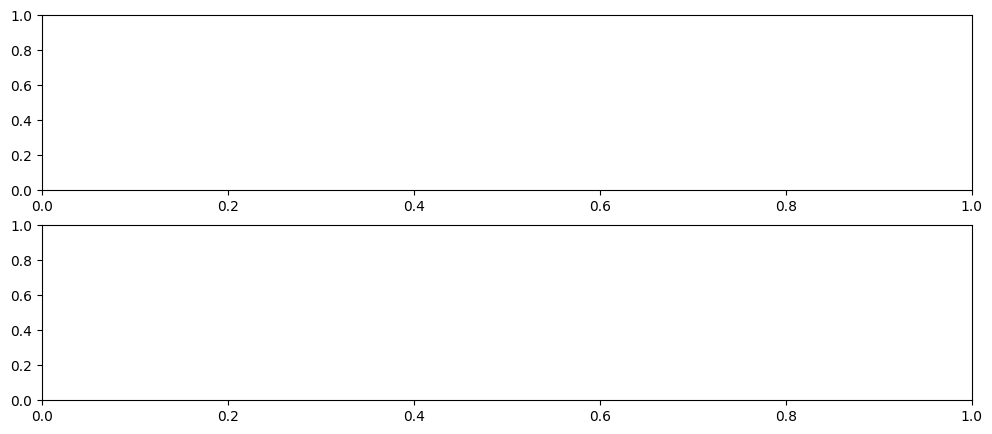

In [4]:
# Parameters
N = 2000    # number of points
d = 16      # feature dimension
alpha = 0.8
sigma = 0.1

# Fixed weight vectors
W0 = torch.randn(d)
A  = torch.randn(d)

# Sample coordinates (conditions) and features
c = torch.rand(N, 2) * 2 - 1     # coords in [-1, 1]^2
z = torch.randn(N, d)

# Spatial modulation factor f(c)
f = torch.sin(math.pi * c[:, 0]) * torch.cos(math.pi * c[:, 1])

# Target values: y = (W(c)^T z) + noise
Wc = W0.unsqueeze(0) + alpha * f.unsqueeze(1) * A.unsqueeze(0)
mean = (Wc * z).sum(dim=1)
eps  = torch.randn_like(mean) * sigma
y    = mean + eps

fig, ax = plt.subplots(2, 1, figsize=(12,5))

# Plot 1: coords colored by target y
sc = plt.scatter(
    c[:, 0],
    c[:, 1],
    c=y,
    cmap='coolwarm',
    s=20,
    alpha=0.8,
    ax=ax[0]
)
ax[0].colorbar(sc, label="Target y value")
ax[0].xlabel("x-1")
ax[0].ylabel("x-2")
ax[0].title("Features (X) colored by Target (y)")
# ax[0].tight_layout()
# ax[0].show()

# Plot 2: coords colored by modulation factor f(c)
sc = plt.scatter(
    c[:, 0],
    c[:, 1],
    c=f,
    cmap='viridis',
    s=20,
    alpha=0.8,
    ax=ax[1]
)
ax[1].colorbar(sc, label="f(c) = sin(pi x) * cos(pi y)")
ax[1].xlabel("x-1")
ax[1].ylabel("x-2")
ax[1].title("Features (X) colored by Conditions (f)")

plt.tight_layout()
plt.show()

In [2]:
# -------------------------------
# Utilities & data generation
# -------------------------------
def set_seed(seed: int = 0):
    torch.manual_seed(seed)
    np.random.seed(seed)

@dataclass
class RecipeAConfig:
    N_train: int = 20000
    N_val: int = 4000
    N_test: int = 4000
    d: int = 16              # feature dimension
    alpha: float = 0.8       # modulation strength
    sigma: float = 0.1       # noise std
    device: str = "cpu"      # change to "cuda" if available

def generate_recipe_a(cfg: RecipeAConfig):
    """
    Returns (z, c, y) for train/val/test splits.
    z: features (N, d)
    c: coords (N, 2) in [-1, 1]^2
    y: targets (N, 1)
    """
    def make_split(N):
        c = torch.rand(N, 2) * 2 - 1                      # [-1, 1]^2
        z = torch.randn(N, cfg.d)
        # modulation scalar f(c)
        f = torch.sin(math.pi * c[:, 0]) * torch.cos(math.pi * c[:, 1])  # (N,)
        return z, c, f

    # Global (fixed) W0 and A define W(c) = W0 + alpha f(c) A
    W0 = torch.randn(cfg.d)
    A  = torch.randn(cfg.d)

    def build_targets(z, f):
        # y = (W(c)^T z) + eps, with W(c) = W0 + alpha f A
        # Compute per-sample effective weights and dot with z
        Wc = W0.unsqueeze(0) + cfg.alpha * f.unsqueeze(1) * A.unsqueeze(0)  # (N, d)
        mean = (Wc * z).sum(dim=1)                                          # (N,)
        eps = torch.randn_like(mean) * cfg.sigma
        y = (mean + eps).unsqueeze(-1)                                      # (N, 1)
        return y

    z_tr, c_tr, f_tr = make_split(cfg.N_train)
    z_va, c_va, f_va = make_split(cfg.N_val)
    z_te, c_te, f_te = make_split(cfg.N_test)

    y_tr = build_targets(z_tr, f_tr)
    y_va = build_targets(z_va, f_va)
    y_te = build_targets(z_te, f_te)

    # Package and send to device later in training code
    return (z_tr, c_tr, y_tr), (z_va, c_va, y_va), (z_te, c_te, y_te)

In [34]:
from typing import List, Optional, Tuple

import torch
import torch.nn as nn


class ZeroFiLM(nn.Module):
    """
    Feature-wise Linear Modulation (FiLM) layer with optional dropout and residual connection.
    Supports (N, C) tensors. Optionally supports (N, C, H, W) if broadcast_spatial=True.
    """
    def __init__(
            self,
            in_channels: int,
            condition_dim: int,
            condition_list: Optional[List[str]] = None,
            use_bias: bool = True,          # include beta term
            use_dropout: bool = False,      # dropout on generated params
            dropout_prob: float = 0.1,
            use_residual: bool = False,     # add x + residual_weight * FiLM(x)
            residual_weight: float = 1.0,
            broadcast_spatial: bool = False # if True, accepts (N, C, H, W)
        ):
        super().__init__()

        self.in_channels = in_channels
        self.condition_dim = condition_dim
        self.condition_list = condition_list or []
        self.use_bias = use_bias
        self.use_dropout = use_dropout
        self.use_residual = use_residual
        self.residual_weight = residual_weight
        self.broadcast_spatial = broadcast_spatial

        out_dim = in_channels * (2 if use_bias else 1)
        self.param_generator = nn.Linear(condition_dim, out_dim)

        # Proper identity initialization:
        # Make output independent of conditions at init (weights=0),
        # and set bias so that gamma=1, beta=0 (or gamma=1 if no beta).
        nn.init.zeros_(self.param_generator.weight)
        if use_bias:
            with torch.no_grad():
                bias = torch.zeros(out_dim)
                bias[:in_channels] = 1.0   # gamma = 1
                bias[in_channels:] = 0.0   # beta  = 0
                self.param_generator.bias.copy_(bias)
        else:
            nn.init.ones_(self.param_generator.bias)  # gamma = 1

        self.dropout = nn.Dropout(p=dropout_prob) if use_dropout else None


    def _split_params(
            self,
            film_params
        ) -> Tuple[torch.Tensor, torch.Tensor]:
        if self.use_bias:
            gamma, beta = torch.chunk(film_params, 2, dim=-1)
        else:
            gamma, beta = film_params, None
        return gamma, beta


    def forward(
            self,
            x: torch.Tensor,
            conditions: torch.Tensor,
        ) -> torch.Tensor:
        """
        x: (N, C) or (N, C, H, W) if broadcast_spatial=True
        conditions: (N, condition_dim)
        """
        film_params = self.param_generator(conditions)   # (N, C) or (N, 2C)
        gamma, beta = self._split_params(film_params)

        if self.use_dropout and self.training:
            gamma = self.dropout(gamma)
            if beta is not None:
                beta = self.dropout(beta)

        if self.broadcast_spatial:
            # reshape to (N, C, 1, 1) to broadcast over H, W
            shape = [x.size(0), self.in_channels] + [1] * (x.dim() - 2)
            gamma = gamma.view(*shape)
            if beta is not None:
                beta = beta.view(*shape)

        # if self.training:
            # print(f"Gamma Variance: {gamma.var(unbiased=False).item()}")
            # if beta is not None:
                # print(f"Beta Variance: {beta.var(unbiased=False).item()}")

        x_conditioned = gamma * x
        if beta is not None:
            x_conditioned = x_conditioned + beta

        return x + self.residual_weight * x_conditioned if self.use_residual else x_conditioned

In [35]:
from typing import List, Optional, Tuple

import torch
import torch.nn as nn


class OneFiLM(nn.Module):
    """
    Feature-wise Linear Modulation (FiLM) layer with optional dropout and residual connection.
    Supports (N, C) tensors. Optionally supports (N, C, H, W) if broadcast_spatial=True.
    """
    def __init__(
            self,
            in_channels: int,
            condition_dim: int,
            condition_list: Optional[List[str]] = None,
            use_bias: bool = True,          # include beta term
            use_dropout: bool = False,      # dropout on generated params
            dropout_prob: float = 0.1,
            use_residual: bool = False,     # add x + residual_weight * FiLM(x)
            residual_weight: float = 1.0,
            broadcast_spatial: bool = False # if True, accepts (N, C, H, W)
        ):
        super().__init__()

        self.in_channels = in_channels
        self.condition_dim = condition_dim
        self.condition_list = condition_list or []
        self.use_bias = use_bias
        self.use_dropout = use_dropout
        self.use_residual = use_residual
        self.residual_weight = residual_weight
        self.broadcast_spatial = broadcast_spatial

        out_dim = in_channels * (2 if use_bias else 1)
        self.param_generator = nn.Linear(condition_dim, out_dim)

        # Proper identity initialization:
        # Make output dependent of conditions at init (weights=0),
        # and set bias so that gamma=1, beta=0 (or gamma=1 if no beta).
        nn.init.ones_(self.param_generator.weight)
        if use_bias:
            with torch.no_grad():
                bias = torch.zeros(out_dim)
                bias[:in_channels] = 1.0   # gamma = 1
                bias[in_channels:] = 0.0   # beta  = 0
                self.param_generator.bias.copy_(bias)
        else:
            nn.init.ones_(self.param_generator.bias)  # gamma = 1

        self.dropout = nn.Dropout(p=dropout_prob) if use_dropout else None


    def _split_params(
            self,
            film_params
        ) -> Tuple[torch.Tensor, torch.Tensor]:
        if self.use_bias:
            gamma, beta = torch.chunk(film_params, 2, dim=-1)
        else:
            gamma, beta = film_params, None
        return gamma, beta


    def forward(
            self,
            x: torch.Tensor,
            conditions: torch.Tensor,
        ) -> torch.Tensor:
        """
        x: (N, C) or (N, C, H, W) if broadcast_spatial=True
        conditions: (N, condition_dim)
        """
        film_params = self.param_generator(conditions)   # (N, C) or (N, 2C)
        gamma, beta = self._split_params(film_params)

        if self.use_dropout and self.training:
            gamma = self.dropout(gamma)
            if beta is not None:
                beta = self.dropout(beta)

        if self.broadcast_spatial:
            # reshape to (N, C, 1, 1) to broadcast over H, W
            shape = [x.size(0), self.in_channels] + [1] * (x.dim() - 2)
            gamma = gamma.view(*shape)
            if beta is not None:
                beta = beta.view(*shape)

        # if self.training:
            # print(f"Gamma Variance: {gamma.var(unbiased=False).item()}")
            # if beta is not None:
                # print(f"Beta Variance: {beta.var(unbiased=False).item()}")

        x_conditioned = gamma * x
        if beta is not None:
            x_conditioned = x_conditioned + beta

        return x + self.residual_weight * x_conditioned if self.use_residual else x_conditioned

In [41]:
# -------------------------------
# Models
# -------------------------------
class MLP(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, hidden: int = 128, depth: int = 2):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.GELU()]
            d = hidden
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class BaselineModel(nn.Module):
    """Plain MLP that only sees z."""
    def __init__(self, d: int):
        super().__init__()
        self.backbone = MLP(in_dim=d, out_dim=1, hidden=128, depth=2)

    def forward(self, z, c=None):
        return self.backbone(z)

class ZeroFiLMModel(nn.Module):
    """MLP preceded by FiLM that sees (z, c)."""
    def __init__(self, d: int, cond_dim: int = 2):
        super().__init__()
        self.film = ZeroFiLM(in_channels=d, condition_dim=cond_dim, use_bias=True, residual_weight=0.25)
        self.backbone = MLP(in_dim=d, out_dim=1, hidden=128, depth=2)

    def forward(self, z, c):
        z_mod = self.film(z, c)
        return self.backbone(z_mod)
    
class OneFiLMModel(nn.Module):
    """MLP preceded by FiLM that sees (z, c)."""
    def __init__(self, d: int, cond_dim: int = 2):
        super().__init__()
        self.film = OneFiLM(in_channels=d, condition_dim=cond_dim, use_bias=True, residual_weight=0.25)
        self.backbone = MLP(in_dim=d, out_dim=1, hidden=128, depth=2)

    def forward(self, z, c):
        z_mod = self.film(z, c)
        return self.backbone(z_mod)

In [42]:
# -------------------------------
# Training / evaluation
# -------------------------------
def batches(X, C, Y, batch_size=256, shuffle=True):
    N = X.size(0)
    idx = torch.randperm(N) if shuffle else torch.arange(N)
    for i in range(0, N, batch_size):
        j = idx[i:i+batch_size]
        yield X[j], (C[j] if C is not None else None), Y[j]

@torch.no_grad()
def eval_mse(model, z, c, y):
    model.eval()
    pred = model(z, c)
    return F.mse_loss(pred, y).item()

def train_model(model, train, val, cfg: RecipeAConfig, epochs=40, lr=1e-3, batch_size=256):
    (z_tr, c_tr, y_tr) = [t.to(cfg.device) for t in train]
    (z_va, c_va, y_va) = [t.to(cfg.device) for t in val]

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    train_curve, val_curve = [], []

    for ep in range(epochs):
        model.train()
        for xb, cb, yb in batches(z_tr, c_tr, y_tr, batch_size=batch_size, shuffle=True):
            xb, yb = xb.to(cfg.device), yb.to(cfg.device)
            cb = cb.to(cfg.device) if cb is not None else None
            opt.zero_grad()
            pred = model(xb, cb)
            loss = F.mse_loss(pred, yb)
            loss.backward()
            opt.step()

        # Epoch metrics
        tr_mse = eval_mse(model, z_tr, c_tr, y_tr)
        va_mse = eval_mse(model, z_va, c_va, y_va)
        train_curve.append(tr_mse)
        val_curve.append(va_mse)

    return train_curve, val_curve

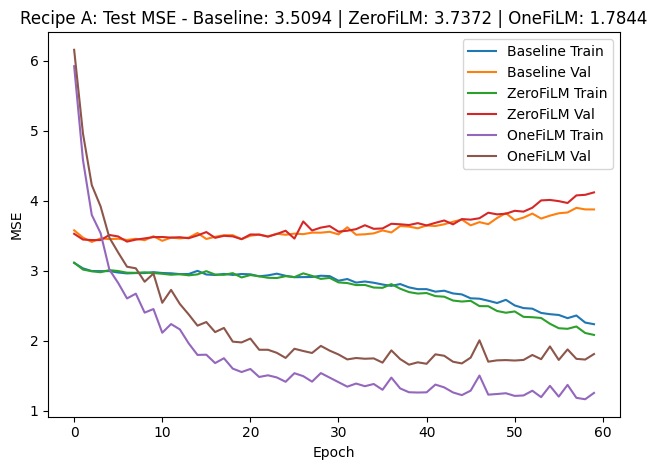

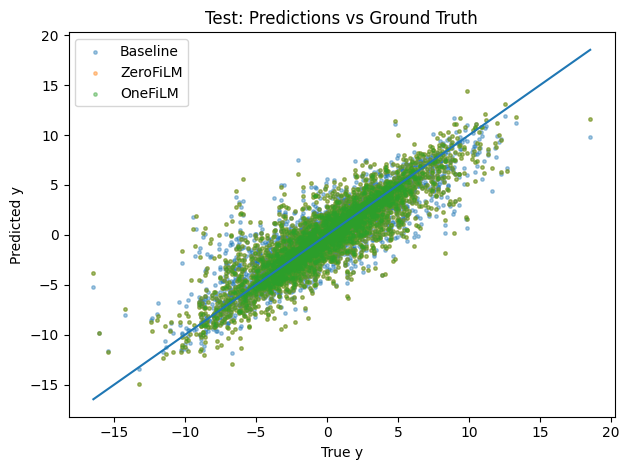

In [43]:
# -------------------------------
# Main experiment + visualization
# -------------------------------
def main():
    set_seed(0)
    cfg = RecipeAConfig()

    # Generate data
    train, val, test = generate_recipe_a(cfg)
    (z_tr, c_tr, y_tr) = [t.to(cfg.device) for t in train]
    (z_va, c_va, y_va) = [t.to(cfg.device) for t in val]
    (z_te, c_te, y_te) = [t.to(cfg.device) for t in test]

    # Build models
    baseline = BaselineModel(d=cfg.d).to(cfg.device)
    zerofilmnet  = ZeroFiLMModel(d=cfg.d, cond_dim=2).to(cfg.device)
    onefilmnet  = OneFiLMModel(d=cfg.d, cond_dim=2).to(cfg.device)

    # Train (keep it short for a quick demo; increase epochs for a larger gap)
    base_tr, base_va = train_model(baseline, train, val, cfg, epochs=60, lr=3e-3, batch_size=512)
    zero_film_tr, zero_film_va = train_model(zerofilmnet,  train, val, cfg, epochs=60, lr=3e-3, batch_size=512)
    one_film_tr, one_film_va = train_model(onefilmnet,  train, val, cfg, epochs=60, lr=3e-3, batch_size=512)

    # Final test MSEs
    base_test = eval_mse(baseline, z_te, None, y_te)
    zero_film_test = eval_mse(zerofilmnet,  z_te, c_te, y_te)
    one_film_test = eval_mse(onefilmnet,  z_te, c_te, y_te)
    # print(f"Test MSE - Baseline: {base_test:.4f} | FiLM: {film_test:.4f}")

    # --- Plots ---
    # 1) Train/Val curves
    plt.figure()
    plt.plot(base_tr, label="Baseline Train")
    plt.plot(base_va, label="Baseline Val")
    plt.plot(zero_film_tr, label="ZeroFiLM Train")
    plt.plot(zero_film_va, label="ZeroFiLM Val")
    plt.plot(one_film_tr, label="OneFiLM Train")
    plt.plot(one_film_va, label="OneFiLM Val")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Recipe A: Test MSE - Baseline: {base_test:.4f} | ZeroFiLM: {zero_film_test:.4f} | OneFiLM: {one_film_test:.4f}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2) Test scatter: y_true vs y_pred
    with torch.no_grad():
        y_pred_base = baseline(z_te, None).cpu().numpy().ravel()
        y_pred_zerofilm = zerofilmnet(z_te, c_te).cpu().numpy().ravel()
        y_pred_onefilm = zerofilmnet(z_te, c_te).cpu().numpy().ravel()
        y_true = y_te.cpu().numpy().ravel()

    lims = (float(min(y_true.min(), y_pred_base.min(), y_pred_zerofilm.min(), y_pred_onefilm.min())),
            float(max(y_true.max(), y_pred_base.max(), y_pred_zerofilm.max(), y_pred_onefilm.max())))

    plt.figure()
    plt.scatter(y_true, y_pred_base, s=6, alpha=0.4, label="Baseline")
    plt.scatter(y_true, y_pred_zerofilm, s=6, alpha=0.4, label="ZeroFiLM")
    plt.scatter(y_true, y_pred_onefilm, s=6, alpha=0.4, label="OneFiLM")
    plt.plot(lims, lims)
    plt.xlabel("True y")
    plt.ylabel("Predicted y")
    plt.title("Test: Predictions vs Ground Truth")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # # 3) Visualize f(c) distribution (sanity)
    # f_val = torch.sin(math.pi * c_te[:, 0]) * torch.cos(math.pi * c_te[:, 1])
    # plt.figure()
    # plt.hist(f_val.cpu().numpy(), bins=40)
    # plt.xlabel("f(c) = sin(pi x) * cos(pi y)")
    # plt.ylabel("Count")
    # plt.title("Distribution of spatial modulation f(c) on test set")
    # plt.tight_layout()
    # plt.show()

if __name__ == "__main__":
    main()

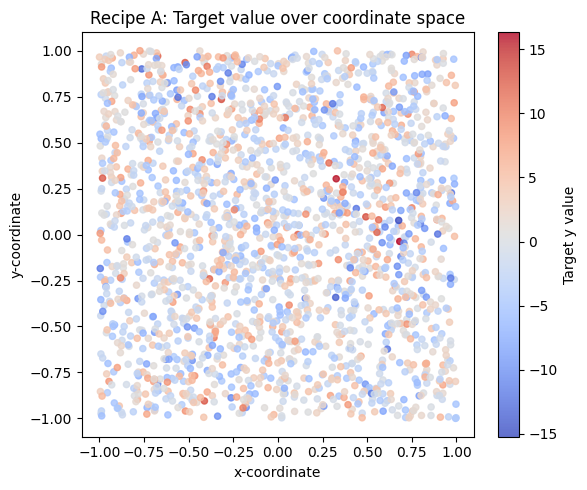

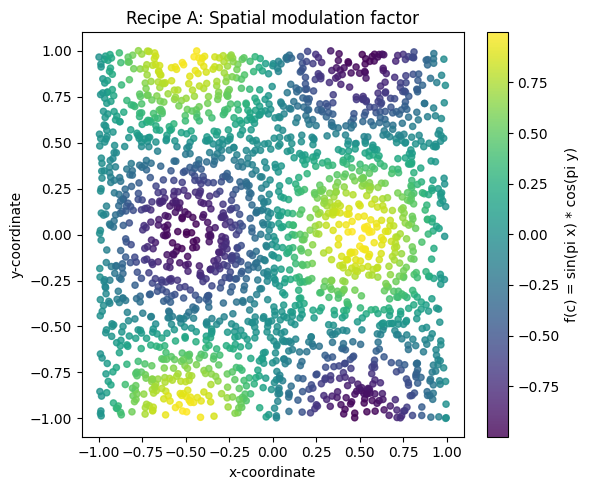